In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from scipy.stats import zscore
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

### Read the input file and check the data dimension

In [2]:
df = pd.read_csv("german_credit.csv")

In [3]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [4]:
df = df.sample(n=500)
#X =  df.drop("default", axis=1)
#y =  df.pop("default")

In [5]:
# Lets build a Ensemble model but need to modify the dataset first
#test_size = 0.30 # taking 50:50 training and test set
#seed = 7  # Random numbmer seeding for reapeatability of the code
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [6]:
# Print Shape of model data
df.shape

(500, 21)

In [7]:
df_t = pd.get_dummies(df)

In [8]:
df_t.head(10)

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,...,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
391,0,12,983,1,4,19,1,1,1,0,...,0,1,0,0,0,1,1,0,0,1
172,1,24,2064,3,2,34,1,1,1,0,...,1,0,1,0,0,0,0,1,0,1
772,0,21,3275,1,4,36,1,1,0,0,...,1,0,1,0,0,0,0,1,0,1
789,1,40,5998,4,3,27,1,1,0,1,...,1,0,0,1,0,0,0,1,0,1
730,0,24,6403,1,2,33,1,1,1,0,...,1,0,0,1,0,0,1,0,0,1
871,0,6,1343,1,4,46,2,2,0,0,...,1,0,0,1,0,0,1,0,1,0
807,0,12,930,4,4,65,4,1,0,0,...,1,0,0,1,0,0,1,0,0,1
314,0,4,1494,1,2,29,1,2,0,0,...,1,0,0,0,0,1,1,0,1,0
893,0,36,5800,3,4,34,2,1,1,0,...,1,0,0,1,0,0,0,1,0,1
924,1,24,6872,2,1,55,1,1,0,1,...,1,0,0,1,0,0,0,1,0,1


In [9]:
df_t.shape

(500, 62)

### Check for highly correlated variables but don't required any treatment for this use case

In [10]:
df.corr()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
default,1.000000,0.228246,0.130906,0.098184,-0.065878,-0.048211,-0.037914,-0.019504
duration_in_month,0.228246,1.000000,0.685813,0.031714,0.004663,-0.066912,-0.002631,-0.010879
credit_amount,0.130906,0.685813,1.000000,-0.264509,-0.018770,-0.009244,0.031373,0.021604
installment_as_income_perc,0.098184,0.031714,-0.264509,1.000000,0.089462,0.095491,0.032757,-0.056245
present_res_since,-0.065878,0.004663,-0.018770,0.089462,1.000000,0.264279,0.075859,0.091531
age,-0.048211,-0.066912,-0.009244,0.095491,0.264279,1.000000,0.201976,0.164014
credits_this_bank,-0.037914,-0.002631,0.031373,0.032757,0.075859,0.201976,1.000000,0.014747
people_under_maintenance,-0.019504,-0.010879,0.021604,-0.056245,0.091531,0.164014,0.014747,1.000000


### Drop the original variables which are converted to dummy

In [11]:
df = pd.get_dummies(df ,drop_first =True )

In [12]:
df.shape

(500, 49)

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [13]:
X =  df.drop("default", axis=1)
y =  df.pop("default")

In [14]:
test_size = 0.30 # taking 70:50 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [15]:
Rf_model = RandomForestClassifier(criterion='entropy',random_state=0 )

#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'n_estimators':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(Rf_model,parameter,cv=3)
GS.fit(X,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [16]:
GS.best_params_

{'criterion': 'entropy', 'n_estimators': 9}

In [17]:
Rf_model = RandomForestClassifier(n_estimators=500,n_jobs=2,criterion='entropy',random_state=9999 )

In [18]:
Rf_model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [19]:
# make predictions
from sklearn import metrics
predicted = Rf_model.predict(X_test)

In [20]:
acc2=metrics.accuracy_score(y_test,predicted)
print("Accuracy score : " ,acc2)

Accuracy score :  0.74


In [21]:
cm=metrics.confusion_matrix(y_test,predicted)
print(cm)

[[95  3]
 [36 16]]


### Q6 Show the list of the features importance( 1 Marks)

[0.08347377 0.10838606 0.04143657 0.04379368 0.08876737 0.02098326
 0.0128455  0.02236869 0.00954043 0.07714956 0.02087307 0.013076
 0.0214281  0.00652671 0.01214848 0.02753395 0.01762286 0.01647315
 0.00446373 0.00361385 0.01599645 0.0036493  0.00135266 0.02273929
 0.01013496 0.0052819  0.01353829 0.01679116 0.01879213 0.01326186
 0.01070186 0.00482349 0.01106652 0.01855045 0.01069373 0.01329561
 0.01635378 0.0170097  0.01381958 0.01756706 0.00799991 0.01351823
 0.01315776 0.01608802 0.002299   0.01404283 0.01944461 0.00552507]


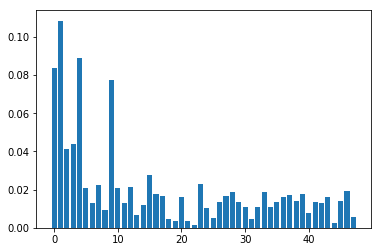

In [22]:
# feature importance
print(Rf_model.feature_importances_)
# plot
plt.bar(range(len(Rf_model.feature_importances_)), Rf_model.feature_importances_)
plt.show()

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [23]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
Dt_model=DecisionTreeClassifier(criterion='entropy',random_state=0)#fully grown tree (high bias error and var error)

In [24]:
# Use below values
num_folds = 10
seed = 77

In [25]:
#Validate the Random Forest model build above using k fold

In [26]:
models = []
models.append(('DecisionTree', Dt_model))
models.append(('RandomForest', Rf_model))


In [27]:
#Calculate Mean score

DecisionTree: 0.442539 (0.009844)
RandomForest: 0.360804 (0.015455)


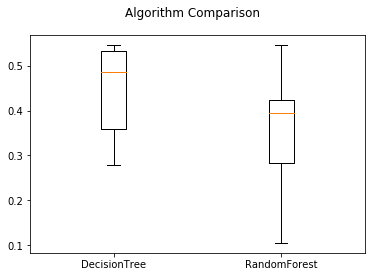

In [28]:
# evaluate each model in turn
results = []
names = []
scoring = 'recall'
for name, model in models:
	kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [29]:
# Calculate score standard deviation using std()

DecisionTree: 0.099218 (0.009844)
RandomForest: 0.124317 (0.015455)


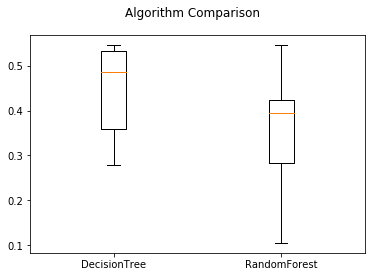

In [30]:
# evaluate each model in turn
results = []
names = []
scoring = 'recall'
for name, model in models:
	kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.std(cv_results), cv_results.var())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# Q8 Print the confusion matrix( 1 Marks)

In [31]:
cm=metrics.confusion_matrix(y_test,predicted)
print(cm)

[[95  3]
 [36 16]]


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [32]:
THRESHOLD = 0.30
preds = np.where(Rf_model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [33]:
pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds),
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.693333
recall,0.750000
precision,0.541667
f1Score,0.629032


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [34]:
#Hint: Use roc_curve

In [35]:
from sklearn.metrics import roc_curve, auc
y_predictProb = Rf_model.predict_proba(X_test)

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])

In [37]:
roc_auc = auc(fpr, tpr)
roc_auc

0.777276295133438

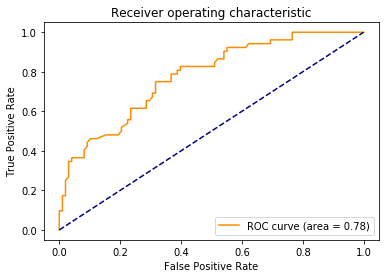

In [38]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [39]:
optimalF1 = 0
optimalTh = 0

In [40]:
for th in thresholds:
    preds = np.where(model.predict_proba(X_test)[:,1] > th, 1, 0)
    f1Score = f1_score(y_test, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        optimalTh = th

In [41]:
THRESHOLD = optimalTh

In [42]:
optimalTh

0.244

In [43]:
preds = np.where(Rf_model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [44]:
pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds),
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.673333
recall,0.826923
precision,0.518072
f1Score,0.637037


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [45]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [46]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [47]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.7186666666666667
Standard deviation:  0.017074997966487593
